# Multi-LLM validation of inferred persona attributes

Inter-rater reliability across the model panel for the two LLM-inferred attributes (no ground truth):

- `financial_security_score` (1–5, ordinal) — all 500 personas
- `relationship_status` (Single/Dating, nominal) — single personas only (~243)

Inputs: `outputs/validation/preds_<tag>_<version>.jsonl` (one per rater × prompt version, produced by `src/validation/run_inference.py`) and `outputs/validation/validation_personas_500.csv`. Set `PROMPT_VERSION` in the first code cell; for a v1-vs-v2 pilot comparison use `src/validation/pilot_report.py` instead.

Statistics: Krippendorff's alpha (ordinal / nominal), pairwise Cohen's kappa (quadratic-weighted for the score), consensus labels (median / majority vote). Works on however many raters have finished — rerun after each model completes.

In [1]:
import glob
import json

import krippendorff
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import cohen_kappa_score

PROMPT_VERSION = "v2"  # which prompt set's predictions to analyse (see src/validation/inference_prompts.py)

personas = pd.read_csv("outputs/validation/validation_personas_500.csv")

frames = []
for path in sorted(glob.glob(f"outputs/validation/preds_*_{PROMPT_VERSION}.jsonl")):
    recs = {}
    with open(path, encoding="utf-8") as f:
        for line in f:
            if line.strip():
                r = json.loads(line)
                recs[r["persona_id"]] = r  # last line per persona wins (resume re-runs)
    frames.append(pd.DataFrame(recs.values()))
preds = pd.concat(frames, ignore_index=True)
preds_ok = preds[preds["error"].isna()]
models = sorted(preds["model_tag"].unique())
print(f"prompt version: {PROMPT_VERSION}, raters: {models}")

coverage = (preds.assign(ok=preds["error"].isna())
            .groupby("model_tag")["ok"].agg(attempted="size", succeeded="sum"))
coverage["errors"] = coverage["attempted"] - coverage["succeeded"]
coverage

prompt version: v2, raters: ['claude-haiku', 'gpt-4o-mini', 'llama-3.1-8b', 'nemotron-120b', 'qwen2.5-14b']


,attempted,succeeded,errors
model_tag,,,
claude-haiku,500,500,0
gpt-4o-mini,500,500,0
llama-3.1-8b,500,500,0
nemotron-120b,500,500,0
qwen2.5-14b,500,500,0


## Financial security score (ordinal, all personas)

In [2]:
fin = preds_ok.pivot(index="persona_id", columns="model_tag", values="fin_score")
print(f"personas with at least one rating: {len(fin)}")
print(f"personas rated by all {len(models)} raters: {len(fin.dropna())}")

if len(models) >= 2:
    # Krippendorff's alpha: reliability_data is raters x units, NaN = missing
    alpha_ord = krippendorff.alpha(
        reliability_data=fin[models].T.values.astype(float),
        level_of_measurement="ordinal",
    )
    print(f"\nKrippendorff's alpha (ordinal): {alpha_ord:.3f}")
    print("rule of thumb: >=0.80 reliable, 0.667-0.80 tentative (Krippendorff 2004)")
else:
    print("\nKrippendorff's alpha needs >=2 raters — run more models first")

print("\nPer-rater mean score (severity bias):")
print(fin[models].mean().round(2).to_string())

personas with at least one rating: 500
personas rated by all 5 raters: 500

Krippendorff's alpha (ordinal): 0.738
rule of thumb: >=0.80 reliable, 0.667-0.80 tentative (Krippendorff 2004)

Per-rater mean score (severity bias):
model_tag
claude-haiku     2.84
gpt-4o-mini      2.93
llama-3.1-8b     3.15
nemotron-120b    2.73
qwen2.5-14b      3.10


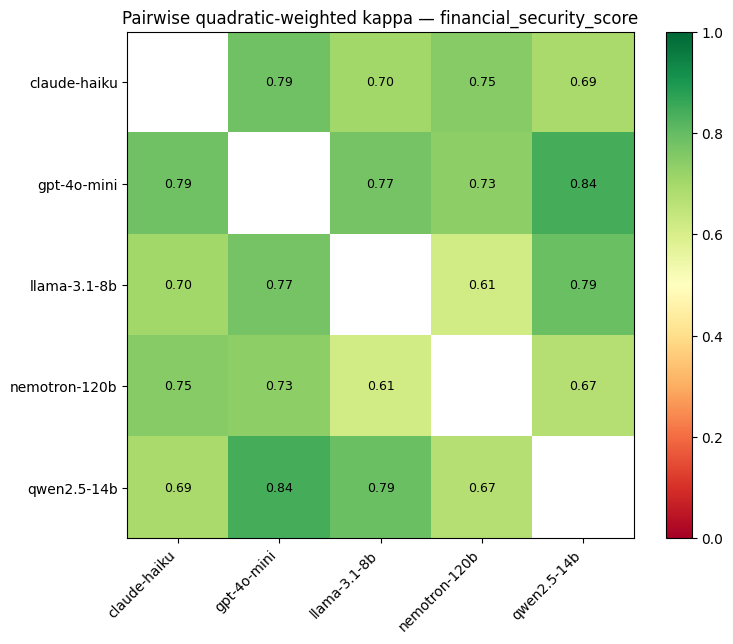

In [3]:
# Pairwise quadratic-weighted Cohen's kappa heatmap
k = len(models)
kappa = np.full((k, k), np.nan)
for i, a in enumerate(models):
    for j, b in enumerate(models):
        pair = fin[[a, b]].dropna()
        if i != j and len(pair):
            kappa[i, j] = cohen_kappa_score(pair[a], pair[b], weights="quadratic")

fig, ax = plt.subplots(figsize=(1.2 * k + 2, 1.0 * k + 1.5))
im = ax.imshow(kappa, cmap="RdYlGn", vmin=0, vmax=1)
ax.set_xticks(range(k), models, rotation=45, ha="right")
ax.set_yticks(range(k), models)
ax.set_title("Pairwise quadratic-weighted kappa — financial_security_score")
for i in range(k):
    for j in range(k):
        if i != j:
            ax.text(j, i, f"{kappa[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

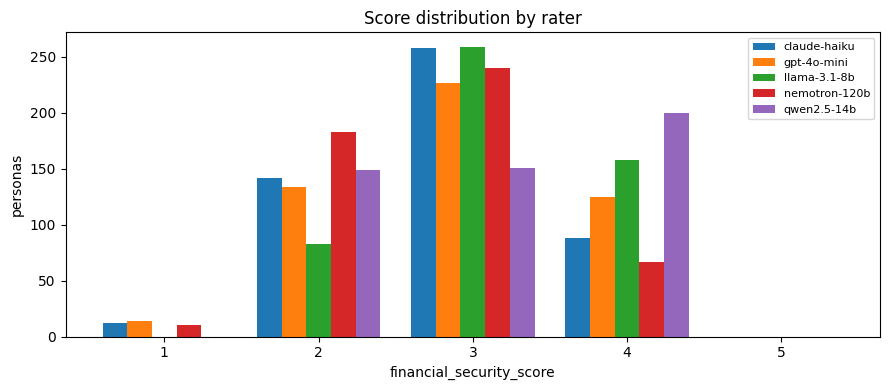

In [4]:
# Score distribution per rater
scores = [1, 2, 3, 4, 5]
x = np.arange(len(scores))
w = 0.8 / len(models)
fig, ax = plt.subplots(figsize=(9, 4))
for m_idx, m in enumerate(models):
    counts = fin[m].value_counts().reindex(scores, fill_value=0)
    ax.bar(x + (m_idx - (len(models) - 1) / 2) * w, counts, w, label=m)
ax.set_xticks(x, scores)
ax.set_xlabel("financial_security_score")
ax.set_ylabel("personas")
ax.set_title("Score distribution by rater")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

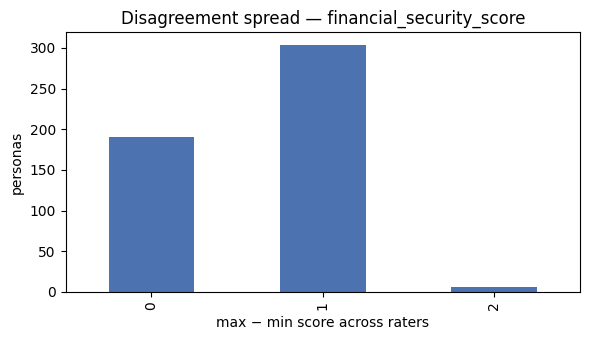

fin_spread
0    190
1    304
2      6
Name: count, dtype: int64

In [5]:
# Consensus (median) and disagreement spread
fin_stats = pd.DataFrame({
    "fin_consensus_median": fin.median(axis=1),
    "fin_spread": fin.max(axis=1) - fin.min(axis=1),
    "n_raters_fin": fin.notna().sum(axis=1),
})

fig, ax = plt.subplots(figsize=(6, 3.5))
fin_stats["fin_spread"].value_counts().sort_index().plot.bar(ax=ax, color="#4c72b0")
ax.set_xlabel("max − min score across raters")
ax.set_ylabel("personas")
ax.set_title("Disagreement spread — financial_security_score")
plt.tight_layout()
plt.show()

fin_stats["fin_spread"].value_counts().sort_index()

In [6]:
# Worst disagreements: all raters' scores and reasoning side by side
worst_ids = fin_stats.sort_values("fin_spread", ascending=False).head(5).index
for pid in worst_ids:
    p = personas.set_index("persona_id").loc[pid]
    print("=" * 100)
    print(f"{pid}: {p['age']}yo {p['gender']}, {p['education']}, "
          f"{p['occupation']} ({p['industry']}), {p['planning_area']}")
    rows = preds_ok[preds_ok["persona_id"] == pid].sort_values("fin_score")
    for _, r in rows.iterrows():
        print(f"  [{r['fin_score']}] {r['model_tag']}: {r['fin_reasoning']}")

V114: 23yo male, University, Unemployed (nan), Pasir Ris
  [1] gpt-4o-mini: Charlie is currently unemployed, which places him in a low financial security category. Despite his university education and aspirations in data analytics, his lack of income and savings, combined with the uncertainty of job placement in a competitive field, indicates significant financial vulnerability.
  [2] claude-haiku: Charlie is currently unemployed at age 23 despite holding a university degree, which suggests he is in early career transition rather than established employment. His Pasir Ris HDB location and lack of current income indicate limited financial buffer, though his university education and clear career trajectory (targeting data analytics roles with planned certifications) suggest medium-term earning potential. The combination of zero current income, early career stage, and reliance on likely parental or modest savings places him in the lower-middle category, though his qualifications and concr

## Relationship status (nominal, single personas only)

In [7]:
single_ids = personas.loc[personas["rel_status"] == "single", "persona_id"]
rel = (preds_ok[preds_ok["persona_id"].isin(single_ids)]
       .pivot(index="persona_id", columns="model_tag", values="rel_status"))
print(f"single personas rated: {len(rel)}")

rel_num = rel.replace({"Single": 0, "Dating": 1})
try:
    alpha_nom = krippendorff.alpha(
        reliability_data=rel_num[models].T.values.astype(float),
        level_of_measurement="nominal",
    )
    print(f"Krippendorff's alpha (nominal): {alpha_nom:.3f}")
except ValueError as e:
    # <2 raters, or no variation yet (e.g. every rating "Single" in a smoke run)
    print(f"Krippendorff's alpha not computable yet: {e}")

print("\nPer-rater % judged Dating:")
print((rel_num[models].mean() * 100).round(1).to_string())

kappa_rel = np.full((len(models), len(models)), np.nan)
for i, a in enumerate(models):
    for j, b in enumerate(models):
        pair = rel[[a, b]].dropna()
        if i != j and len(pair) and pair[a].nunique() > 1 and pair[b].nunique() > 1:
            kappa_rel[i, j] = cohen_kappa_score(pair[a], pair[b])
pd.DataFrame(kappa_rel, index=models, columns=models).round(2)

single personas rated: 243
Krippendorff's alpha (nominal): -0.026

Per-rater % judged Dating:
model_tag
claude-haiku      3.7
gpt-4o-mini       0.0
llama-3.1-8b     21.0
nemotron-120b     0.4
qwen2.5-14b       0.0


,claude-haiku,gpt-4o-mini,llama-3.1-8b,nemotron-120b,qwen2.5-14b
claude-haiku,NaN,NaN,0.00,0.19,NaN
gpt-4o-mini,NaN,NaN,NaN,NaN,NaN
llama-3.1-8b,0.00,NaN,NaN,-0.01,NaN
nemotron-120b,0.19,NaN,-0.01,NaN,NaN
qwen2.5-14b,NaN,NaN,NaN,NaN,NaN


In [8]:
# Majority-vote consensus; ties broken by the gpt-4.1 anchor (flagged)
ANCHOR = "gpt-4.1"

def rel_consensus(row):
    votes = row.dropna()
    counts = votes.value_counts()
    if len(counts) == 1:
        return pd.Series({"rel_consensus": counts.index[0],
                          "rel_unanimous": True, "rel_tie": False})
    if counts.iloc[0] > counts.iloc[1]:
        return pd.Series({"rel_consensus": counts.index[0],
                          "rel_unanimous": False, "rel_tie": False})
    winner = votes.get(ANCHOR, counts.index[0])  # tie -> anchor's vote
    return pd.Series({"rel_consensus": winner,
                      "rel_unanimous": False, "rel_tie": True})

rel_stats = rel.apply(rel_consensus, axis=1)
print(rel_stats[["rel_unanimous", "rel_tie"]].sum().to_string())
print("\nConsensus distribution:")
print(rel_stats["rel_consensus"].value_counts().to_string())

# Disagreement examples with reasoning
split_ids = rel_stats[~rel_stats["rel_unanimous"]].index[:5]
for pid in split_ids:
    print("=" * 100)
    rows = preds_ok[preds_ok["persona_id"] == pid]
    for _, r in rows.iterrows():
        print(f"  [{r['rel_status']}] {r['model_tag']}: {r['rel_reasoning']}")

rel_unanimous    185
rel_tie            0

Consensus distribution:
rel_consensus
Single    243
  [Single] claude-haiku: At 22 and early in his career as an Associate Professional, Jiun Ming's profile emphasizes individual pursuits and peer group activities rather than couple-oriented priorities. His leisure time centers on friend-based activities (coffee-hopping, badminton with friends, gaming), solitary creative outlets (photography, DIY electronics), and career ambitions (certifications, part-time master's degree), with no mention of a romantic partner, shared couple activities, or relationship-building as a life priority. The absence of any romantic reference combined with his focus on self-development and friend groups at this life stage suggests he is currently single.
  [Single] gpt-4o-mini: Jiun Ming's profile emphasizes his hobbies and social activities with friends, such as coffee-shop hopping and playing badminton, without any mention of a romantic partner or dating activitie

In [9]:
# Export consensus labels + per-persona agreement metrics
consensus = fin_stats.join(rel_stats, how="left")
consensus.index.name = "persona_id"
consensus.to_csv("outputs/validation/consensus_labels.csv")
print(f"Saved {len(consensus)} rows to outputs/validation/consensus_labels.csv")
consensus.head(10)

Saved 500 rows to outputs/validation/consensus_labels.csv

,fin_consensus_median,fin_spread,n_raters_fin,rel_consensus,rel_unanimous,rel_tie
persona_id,,,,,,
V001,2.0,1,5,NaN,NaN,NaN
V002,3.0,1,5,Single,False,False
V003,2.0,0,5,NaN,NaN,NaN
V004,4.0,1,5,Single,True,False
V005,3.0,1,5,Single,True,False
V006,2.0,0,5,NaN,NaN,NaN
V007,1.0,1,5,NaN,NaN,NaN
V008,3.0,1,5,Single,True,False
V009,2.0,1,5,Single,False,False
